# Data Cleaning — Smart Attendance System (Biometric IoT Data)

Raw data currently represents **employee** attendance captured via fingerprint sensors at gate devices. The same pipeline will later be reused for **student** attendance data supplied by the IoT team, so cleaning logic here is written to generalize (no employee-specific assumptions baked in beyond column names).

In [1]:
import pandas as pd

df = pd.read_excel('../data/raw/Smart_A_S_D.xlsx')

print(df.shape)
df.info()

(10000, 23)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     10000 non-null  int64  
 1   timestamp                     10000 non-null  str    
 2   device_id                     10000 non-null  str    
 3   employee_id                   10000 non-null  str    
 4   department                    8233 non-null   str    
 5   shift                         8211 non-null   str    
 6   scheduled_start               9834 non-null   str    
 7   scheduled_end                 9834 non-null   str    
 8   event_type                    10000 non-null  str    
 9   fingerprint_id                10000 non-null  int64  
 10  fingerprint_match             10000 non-null  str    
 11  authentication_time_ms        10000 non-null  float64
 12  attempt_number                10000 non-null  int64  
 13  f

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
timestamp,10000,9949,2026-05-06 06:02:45,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_id,10000,4,GATE-02,5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_id,10000,83,UNVERIFIED,1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,8233,7,Production,3422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,8211,4,Night,2738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_start,9834,4,22:00:00,3272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_end,9834,4,06:00:00,3272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,10000,5,Check-In,4148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fingerprint_id,10000.0,NaN,NaN,NaN,848.4298,393.394619,0.0,1006.0,1024.0,1042.0,1084.0


In [3]:
df.head()

,record_id,timestamp,device_id,employee_id,department,shift,scheduled_start,scheduled_end,event_type,fingerprint_id,...,failed_attempt_count_session,enrollment_status,is_late,is_early_exit,device_status,device_health_score,wifi_rssi_dbm,system_uptime_hr,database_sync_status,alert_type
0,1,2026-05-01 03:16:45,GATE-03,UNVERIFIED,NaN,NaN,NaN,NaN,Unauthorized Attempt,0,...,0,NaN,No,No,ONLINE,96.0,-67.6,3.279,SYNCED,Unknown Fingerprint
1,2,2026-05-01 05:40:46,GATE-02,E1037,Production,Morning,06:00:00,14:00:00,Check-In,1037,...,0,NaN,No,No,ONLINE,96.2,-54.0,5.680,SYNCED,NaN
2,3,2026-05-01 05:46:13,GATE-02,E1015,Production,Morning,06:00:00,14:00:00,Check-In,1015,...,0,NaN,No,No,ONLINE,93.8,-60.5,5.771,SYNCED,NaN
3,4,2026-05-01 05:46:46,GATE-01,E1008,Quality Control,Morning,06:00:00,14:00:00,Check-In,1008,...,0,NaN,No,No,ONLINE,95.2,-48.0,5.780,SYNCED,NaN
4,5,2026-05-01 05:47:13,GATE-02,E1058,Maintenance,Morning,06:00:00,14:00:00,Check-In,1058,...,0,NaN,No,No,ONLINE,95.8,-64.9,5.787,SYNCED,NaN


In [4]:
df.isnull().sum()

record_id                          0
timestamp                          0
device_id                          0
employee_id                        0
department                      1767
shift                           1789
scheduled_start                  166
scheduled_end                    166
event_type                         0
fingerprint_id                     0
fingerprint_match                  0
authentication_time_ms             0
attempt_number                     0
failed_attempt_count_session       0
enrollment_status               9968
is_late                            0
is_early_exit                      0
device_status                      0
device_health_score                0
wifi_rssi_dbm                      0
system_uptime_hr                   0
database_sync_status               0
alert_type                      7148
dtype: int64

## Investigating *why* values are missing

Before imputing anything, check whether missingness is random or whether it actually encodes information. Filling everything with the column mode is only valid for the first case — for the second, mode-filling destroys the signal.

In [5]:
# Is department missing exactly when the fingerprint match failed?
print(pd.crosstab(df['department'].isnull(), df['fingerprint_match']))

# What event types have no shift assigned?
print("\nMissing shift by event_type:")
print(df[df['shift'].isnull()]['event_type'].value_counts())

# What event types have no schedule?
print("\nMissing scheduled_start by event_type:")
print(df[df['scheduled_start'].isnull()]['event_type'].value_counts())

# When is enrollment_status actually populated?
print("\nenrollment_status populated for event_type:")
print(df[df['enrollment_status'].notnull()]['event_type'].value_counts())

# What does alert_type=NaN correspond to?
print("\nalert_type missing count vs total:", df['alert_type'].isnull().sum(), "/", len(df))

fingerprint_match    No   Yes
department                   
False                 0  8233
True               1767     0

Missing shift by event_type:
event_type
Check-In/Out Attempt    1623
Unauthorized Attempt     134
Enrollment                32
Name: count, dtype: int64

Missing scheduled_start by event_type:
event_type
Unauthorized Attempt    134
Enrollment               32
Name: count, dtype: int64

enrollment_status populated for event_type:
event_type
Enrollment    32
Name: count, dtype: int64

alert_type missing count vs total: 7148 / 10000


**Findings:**
- `department` / `shift` are missing *only* for unmatched fingerprints, walk-up attempts, unauthorized attempts, and enrollment events — i.e. the system genuinely doesn't know who the person is or hasn't assigned them a shift yet. This is **not random missingness** — filling it with the most common department would mislabel unauthorized/unverified people as legitimate staff.
- `scheduled_start` / `scheduled_end` are missing only for `Unauthorized Attempt` and `Enrollment` events, which have no shift schedule by definition.
- `enrollment_status` is only ever populated for `Enrollment` events (32 rows) — for every other event type it is simply not applicable, not "unknown."
- `alert_type` is NaN for 7,148/10,000 rows — this almost certainly means **no alert was raised**, not that the alert type is unknown.

So each column gets a targeted fix instead of a blanket mode-fill.

In [6]:
df['department']       = df['department'].fillna('Unknown')
df['shift']             = df['shift'].fillna('Unknown')
df['scheduled_start']   = df['scheduled_start'].fillna('Not Scheduled')
df['scheduled_end']     = df['scheduled_end'].fillna('Not Scheduled')
df['enrollment_status'] = df['enrollment_status'].fillna('Not Applicable')
df['alert_type']        = df['alert_type'].fillna('No Alert')

df.isnull().sum()

record_id                       0
timestamp                       0
device_id                       0
employee_id                     0
department                      0
shift                           0
scheduled_start                 0
scheduled_end                   0
event_type                      0
fingerprint_id                  0
fingerprint_match               0
authentication_time_ms          0
attempt_number                  0
failed_attempt_count_session    0
enrollment_status               0
is_late                         0
is_early_exit                   0
device_status                   0
device_health_score             0
wifi_rssi_dbm                   0
system_uptime_hr                0
database_sync_status            0
alert_type                      0
dtype: int64

In [7]:
# Convert timestamp to a proper datetime dtype here (once), so every downstream notebook inherits it
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df.dtypes

record_id                                int64
timestamp                       datetime64[us]
device_id                                  str
employee_id                                str
department                                 str
shift                                      str
scheduled_start                            str
scheduled_end                              str
event_type                                 str
fingerprint_id                           int64
fingerprint_match                          str
authentication_time_ms                 float64
attempt_number                           int64
failed_attempt_count_session             int64
enrollment_status                          str
is_late                                    str
is_early_exit                              str
device_status                              str
device_health_score                    float64
wifi_rssi_dbm                          float64
system_uptime_hr                       float64
database_sync

In [8]:
df.duplicated().sum()

np.int64(0)

## Outlier detection

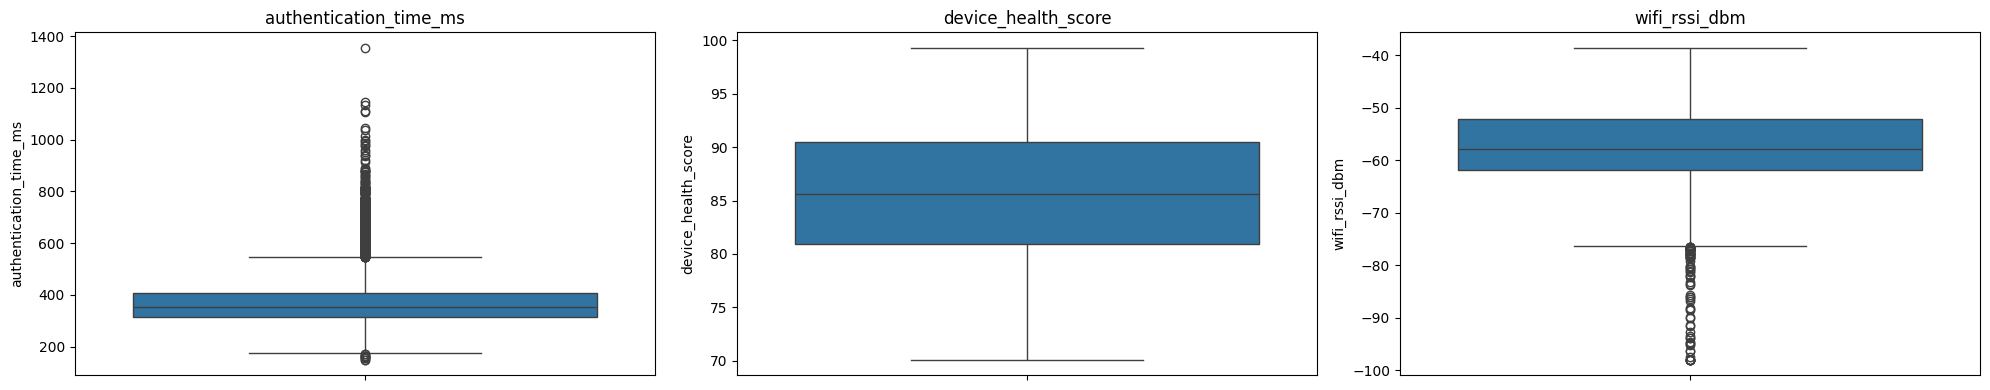

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['authentication_time_ms', 'device_health_score', 'wifi_rssi_dbm']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [10]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | bounds ({lower:.2f}, {upper:.2f})")
    return outliers

for col in numeric_cols:
    find_outliers_iqr(df, col)

authentication_time_ms: 770 outliers | bounds (174.09, 545.79)
device_health_score: 0 outliers | bounds (66.50, 104.90)
wifi_rssi_dbm: 84 outliers | bounds (-76.45, -37.65)


**Decision: outliers are kept, not removed.**

In a biometric security context, an unusually high `authentication_time_ms` or a weak `wifi_rssi_dbm` reading isn't necessarily bad data — it can be a genuine signal (sensor struggling, repeated fingerprint attempts, a device at the edge of WiFi range). Removing these would delete exactly the anomalies an anomaly-detection layer downstream is supposed to catch. They're flagged here for visibility, not deleted.

## Pearson Correlation

Measures the **linear** relationship between two continuous numerical features. Assumes roughly normally distributed data. Breaks down when the relationship plateaus after an initial rapid rise.

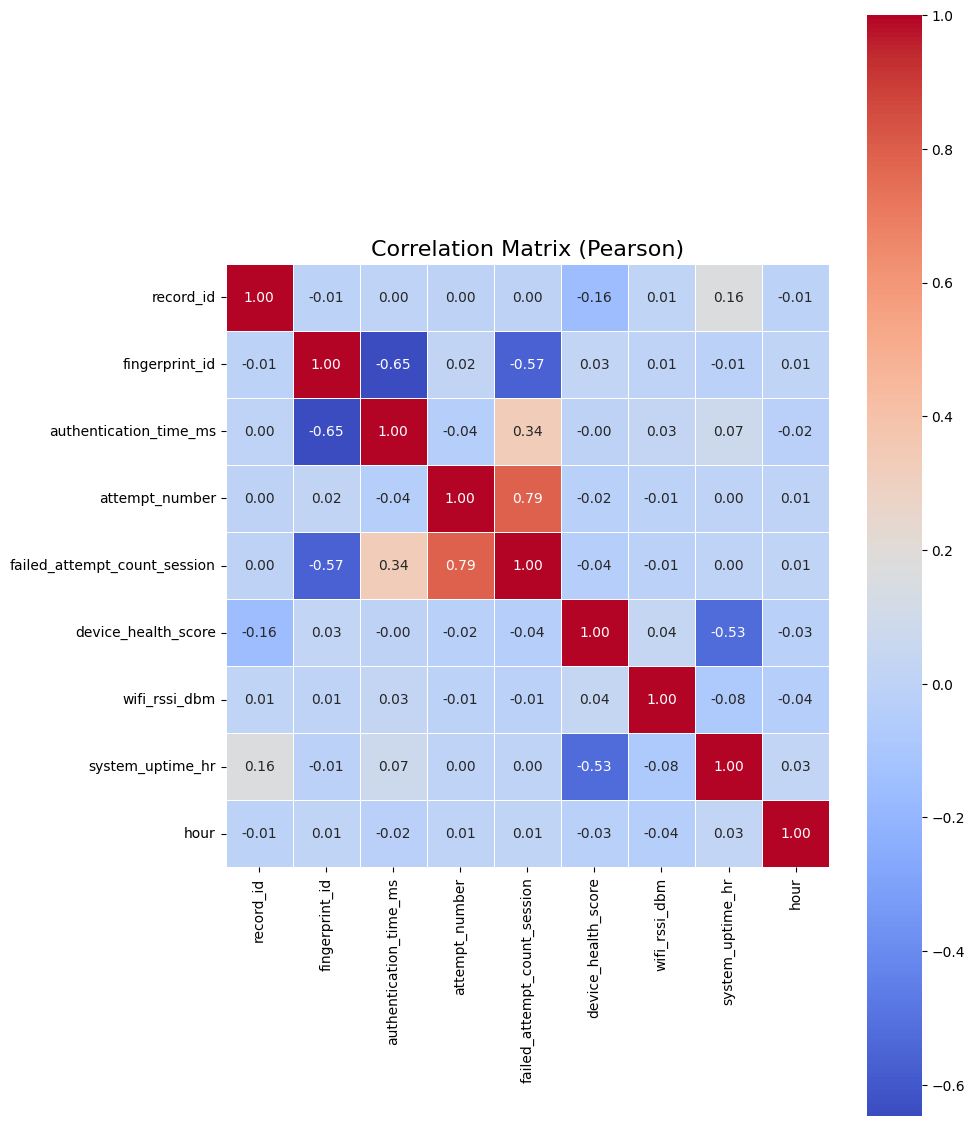

In [11]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr(method='pearson')

plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar=True)
plt.title("Correlation Matrix (Pearson)", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Spearman Correlation

Measures the **monotonic** relationship between two features by correlating their ranks rather than raw values. Useful for ordinal data or when outliers are present, since it is not sensitive to them the way Pearson is.

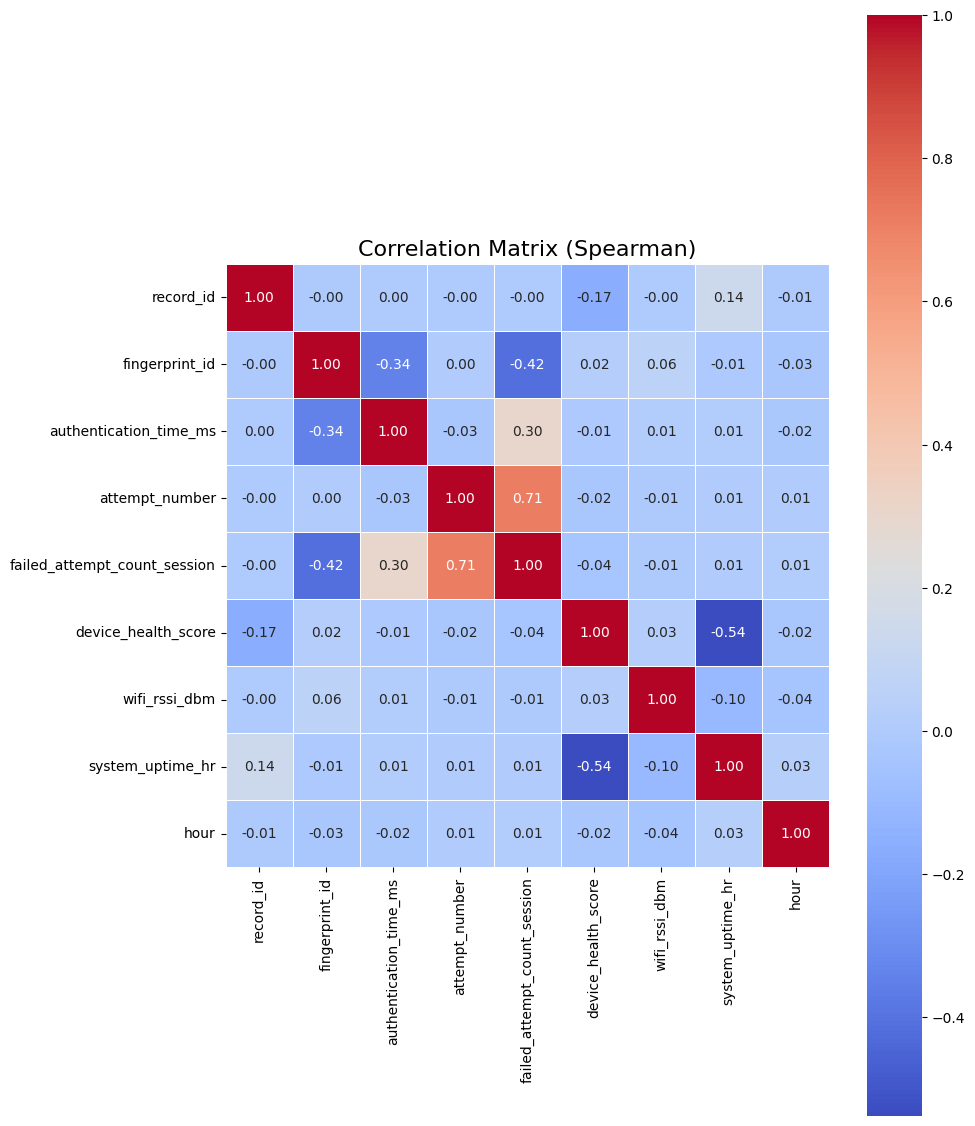

In [12]:
corr_matrix_sp = numeric_df.corr(method='spearman')

plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix_sp, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar=True)
plt.title("Correlation Matrix (Spearman)", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Row count:", len(df))

df.to_csv('../data/processed/cleaned_data.csv', index=False)
print("Saved to ../data/processed/cleaned_data.csv")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   record_id                     10000 non-null  int64         
 1   timestamp                     10000 non-null  datetime64[us]
 2   device_id                     10000 non-null  str           
 3   employee_id                   10000 non-null  str           
 4   department                    10000 non-null  str           
 5   shift                         10000 non-null  str           
 6   scheduled_start               10000 non-null  str           
 7   scheduled_end                 10000 non-null  str           
 8   event_type                    10000 non-null  str           
 9   fingerprint_id                10000 non-null  int64         
 10  fingerprint_match             10000 non-null  str           
 11  authentication_time_ms        10000 non-